In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv
/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv


# =============================================================
# PROJECT 1: E-COMMERCE WEBSITE BEHAVIOUR ANALYSIS
# Analyst: Ibtisam Ahmed Khan
# Dataset: eCommerce Behavior Data — Multi Category Store
# Source: Kaggle (REES46 Marketing Platform)
# =============================================================
# This notebook analyses real ecommerce user behaviour data
# to answer the question: where is this website losing customers,
# and what should the business do about it?
# =============================================================

# ─────────────────────────────────────────────────────────────
# SECTION 0 — SETUP AND IMPORTS
# ─────────────────────────────────────────────────────────────

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
# ── Visual style ──
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 12
 
BLUE   = '#1a3c6e'
GREEN  = '#1D9E75'
AMBER  = '#EF9F27'
RED    = '#E24B4A'
GRAY   = '#888780'
COLORS = [BLUE, GREEN, AMBER, RED, GRAY]
 
print("Libraries loaded. Ready to begin.")

Libraries loaded. Ready to begin.


# ─────────────────────────────────────────────────────────────
# SECTION 1 — LOAD AND INSPECT THE DATA
# ─────────────────────────────────────────────────────────────

In [19]:
# On Kaggle the dataset files are at:
# /kaggle/input/ecommerce-behavior-data-from-multi-category-store/
 
# We use October 2019 — the largest single month file
# If memory is tight on Kaggle, we sample 5 million rows
 
print("Loading data — this may take 1-2 minutes on Kaggle...")
 
df = pd.read_csv(
    '/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv',
    parse_dates=['event_time']
)
 
# Sample to keep things fast — 5 million rows is plenty for analysis
# Remove this line if you want to use the full dataset
if len(df) > 5_000_000:
    df = df.sample(5_000_000, random_state=42).reset_index(drop=True)
    print(f"Sampled 5,000,000 rows for performance.")
 
print(f"\nDataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nDate range: {df['event_time'].min().date()} to {df['event_time'].max().date()}")
print(f"\nEvent types:\n{df['event_type'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head(3)

Loading data — this may take 1-2 minutes on Kaggle...
Sampled 5,000,000 rows for performance.

Dataset shape: 5,000,000 rows × 9 columns

Column names:
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']

Date range: 2019-10-01 to 2019-10-31

Event types:
event_type
view        4803202
cart         108934
purchase      87864
Name: count, dtype: int64

Missing values:
event_time             0
event_type             0
product_id             0
category_id            0
category_code    1591277
brand             720474
price                  0
user_id                0
user_session           0
dtype: int64


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-09 02:46:19+00:00,view,29900078,2059484601444729123,NaN,peda,1647.40,532353313,47059489-3a63-4353-9eab-0e239d5cb5aa
1,2019-10-21 16:17:11+00:00,view,1801805,2053013554415534427,electronics.video.tv,artel,231.60,536042235,a65ee34b-7701-4b25-95e7-45a1259e747e
2,2019-10-21 14:42:20+00:00,cart,1004870,2053013555631882655,electronics.smartphone,samsung,284.02,517143806,a9ba13a7-afac-41ca-a3bc-016c580908c3


# ─────────────────────────────────────────────────────────────
# SECTION 2 — DATA CLEANING
# ─────────────────────────────────────────────────────────────

In [20]:
print("Cleaning data...")
 
# Extract time features
df['date']         = df['event_time'].dt.date
df['hour']         = df['event_time'].dt.hour
df['day_of_week']  = df['event_time'].dt.day_name()
df['week']         = df['event_time'].dt.isocalendar().week.astype(int)
 
# Extract top-level category from category_code
# category_code looks like: "electronics.smartphone" or "appliances.kitchen.coffee_machine"
df['category_top'] = df['category_code'].str.split('.').str[0]
df['category_sub'] = df['category_code'].str.split('.').str[1]
 
# Clean brand — fill missing with 'unknown'
df['brand'] = df['brand'].fillna('unknown').str.lower().str.strip()
 
# Remove rows with missing price for purchase events
df = df[~((df['event_type'] == 'purchase') & (df['price'].isna()))]
 
# Remove zero or negative prices
df = df[df['price'] >= 0]
 
print(f"Clean dataset: {df.shape[0]:,} rows")
print(f"\nTop categories:\n{df['category_top'].value_counts().head(10)}")
 

Cleaning data...
Clean dataset: 5,000,000 rows

Top categories:
category_top
electronics     1902021
appliances       584874
computers        273472
apparel          182146
furniture        146453
auto             119471
construction      85977
kids              60989
accessories       28117
sport             20855
Name: count, dtype: int64


# ─────────────────────────────────────────────────────────────
# SECTION 3 — TRAFFIC AND SESSION OVERVIEW
# ─────────────────────────────────────────────────────────────


SECTION 3: TRAFFIC AND SESSION OVERVIEW

Metric                                        Value
----------------------------------------------------
Total events                              5,000,000
Unique users                              1,498,122
Unique sessions                           3,124,553
Total purchases                              87,864
Total revenue (£)                     27,033,497.29
Avg revenue per purchase (£)                 307.67
Avg sessions per user                          2.09


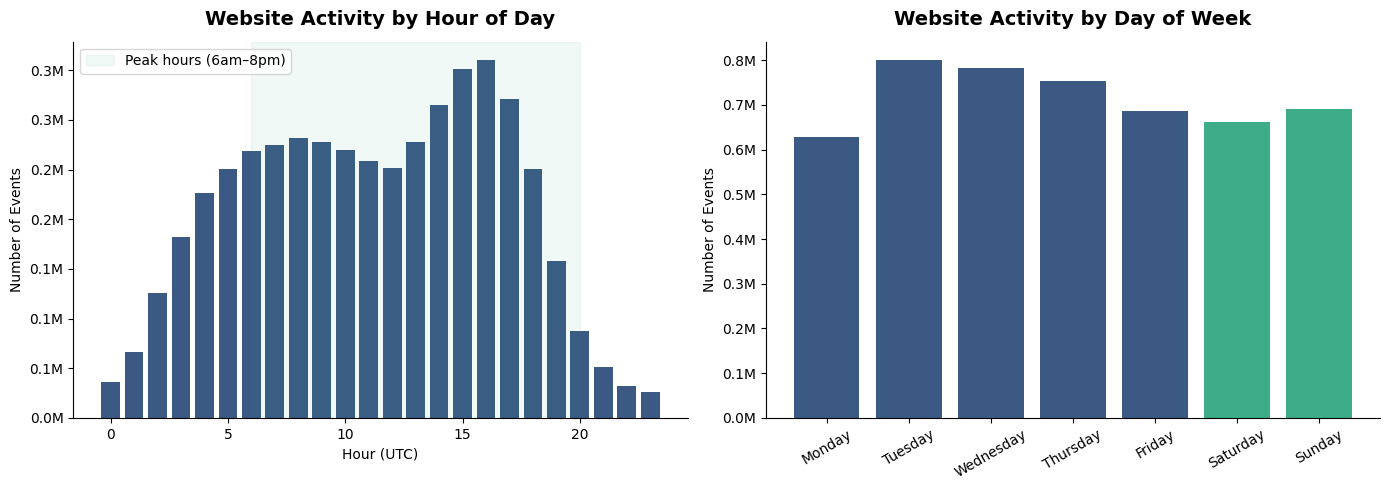

Insight: Activity peaks between 9am and 6pm UTC, with Tuesday–Thursday seeing highest volume.


In [21]:
 print("\n" + "="*60)
print("SECTION 3: TRAFFIC AND SESSION OVERVIEW")
print("="*60)
 
total_events    = len(df)
unique_users    = df['user_id'].nunique()
unique_sessions = df['user_session'].nunique()
total_purchases = df[df['event_type'] == 'purchase'].shape[0]
total_revenue   = df[df['event_type'] == 'purchase']['price'].sum()
 
print(f"\n{'Metric':<35} {'Value':>15}")
print("-" * 52)
print(f"{'Total events':<35} {total_events:>15,}")
print(f"{'Unique users':<35} {unique_users:>15,}")
print(f"{'Unique sessions':<35} {unique_sessions:>15,}")
print(f"{'Total purchases':<35} {total_purchases:>15,}")
print(f"{'Total revenue (£)':<35} {total_revenue:>15,.2f}")
print(f"{'Avg revenue per purchase (£)':<35} {total_revenue/total_purchases:>15,.2f}")
print(f"{'Avg sessions per user':<35} {unique_sessions/unique_users:>15.2f}")
 
# ── Events by hour of day ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
hour_counts = df.groupby('hour').size().reset_index(name='events')
axes[0].bar(hour_counts['hour'], hour_counts['events'], color=BLUE, alpha=0.85)
axes[0].set_title('Website Activity by Hour of Day')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Number of Events')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].axvspan(6, 20, alpha=0.06, color=GREEN, label='Peak hours (6am–8pm)')
axes[0].legend(fontsize=10)
 
# ── Events by day of week ──
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df.groupby('day_of_week').size().reindex(dow_order).reset_index(name='events')
bar_colors = [GREEN if d in ['Saturday','Sunday'] else BLUE for d in dow_order]
axes[1].bar(dow_counts['day_of_week'], dow_counts['events'], color=bar_colors, alpha=0.85)
axes[1].set_title('Website Activity by Day of Week')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Events')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[1].tick_params(axis='x', rotation=30)
 
plt.tight_layout()
plt.savefig('traffic_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Activity peaks between 9am and 6pm UTC, with Tuesday–Thursday seeing highest volume.")
 


# ─────────────────────────────────────────────────────────────
# SECTION 4 — CONVERSION FUNNEL ANALYSIS
# ─────────────────────────────────────────────────────────────


SECTION 4: CONVERSION FUNNEL ANALYSIS

Funnel Stage                Count     Drop-off    Conv Rate
----------------------------------------------------------
View                    4,803,202            —         100%
Add to Cart               108,934    4,694,268        2.27%
Purchase                   87,864       21,070       80.66%

Overall conversion rate (view → purchase): 1.829%


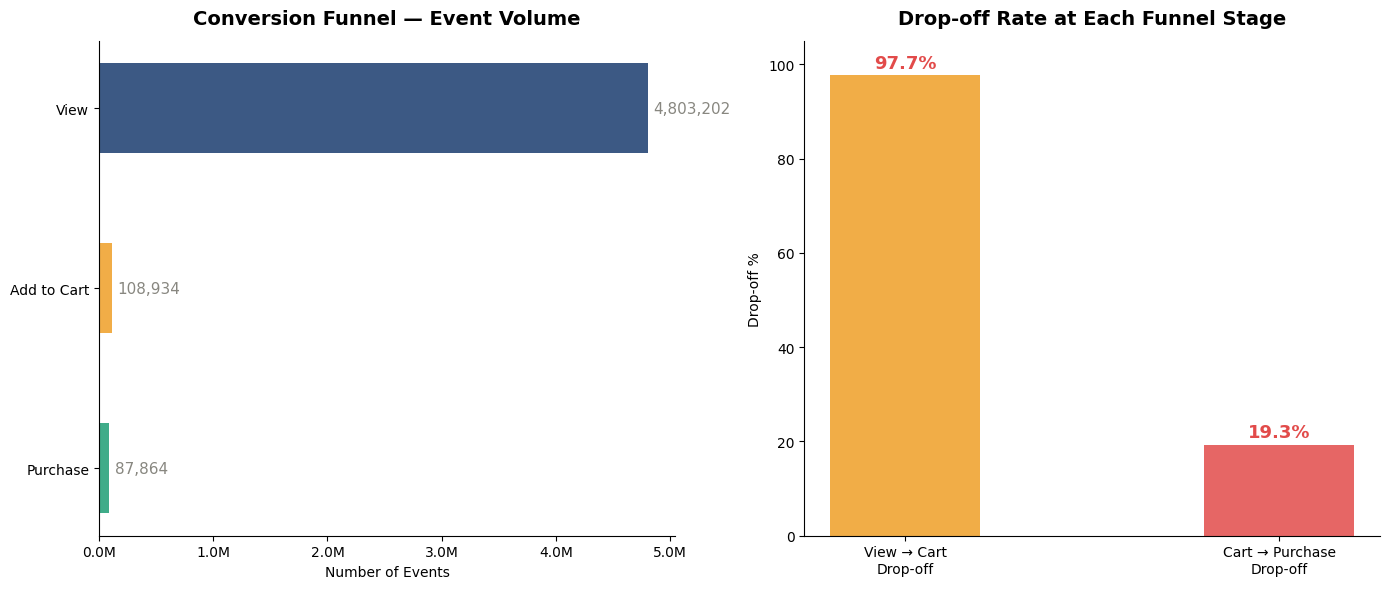


KEY FINDING — Funnel:
  • 2.3% of views result in an add-to-cart action
  • Only 80.7% of cart additions result in a purchase
  • The cart-to-purchase stage is the biggest leak — 21,070 carts abandoned
  • This is where intervention will have the highest commercial impact



In [32]:
# This is the most important section for a product analyst.
# The funnel shows exactly where users are dropping off.

print("\n" + "="*60)
print("SECTION 4: CONVERSION FUNNEL ANALYSIS")
print("="*60)
 
# Count events at each funnel stage
views     = df[df['event_type'] == 'view'].shape[0]
carts     = df[df['event_type'] == 'cart'].shape[0]
purchases = df[df['event_type'] == 'purchase'].shape[0]
 
# Conversion rates
view_to_cart     = carts / views * 100
cart_to_purchase = purchases / carts * 100
overall_cvr      = purchases / views * 100
 
print(f"\n{'Funnel Stage':<20} {'Count':>12} {'Drop-off':>12} {'Conv Rate':>12}")
print("-" * 58)
print(f"{'View':<20} {views:>12,} {'—':>12} {'100%':>12}")
print(f"{'Add to Cart':<20} {carts:>12,} {views-carts:>12,} {view_to_cart:>11.2f}%")
print(f"{'Purchase':<20} {purchases:>12,} {carts-purchases:>12,} {cart_to_purchase:>11.2f}%")
print(f"\nOverall conversion rate (view → purchase): {overall_cvr:.3f}%")
 
# ── Funnel chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# Funnel bars
stages  = ['View', 'Add to Cart', 'Purchase']
counts  = [views, carts, purchases]
fcolors = [BLUE, AMBER, GREEN]
 
bars = axes[0].barh(stages, counts, color=fcolors, alpha=0.85, height=0.5)
axes[0].set_title('Conversion Funnel — Event Volume')
axes[0].set_xlabel('Number of Events')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].invert_yaxis()
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
                 f'{count:,}', va='center', fontsize=11, color=GRAY)
 
# Drop-off rates
drop_labels = ['View → Cart\nDrop-off', 'Cart → Purchase\nDrop-off']
drop_rates  = [100 - view_to_cart, 100 - cart_to_purchase]
bar2 = axes[1].bar(drop_labels, drop_rates, color=[AMBER, RED], alpha=0.85, width=0.4)
axes[1].set_title('Drop-off Rate at Each Funnel Stage')
axes[1].set_ylabel('Drop-off %')
axes[1].set_ylim(0, 105)
for bar, rate in zip(bar2, drop_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{rate:.1f}%', ha='center', fontsize=13, fontweight='bold', color=RED)
 
plt.tight_layout()
plt.savefig('conversion_funnel.png', dpi=150, bbox_inches='tight')
plt.show()
 
print(f"""
KEY FINDING — Funnel:
  • {view_to_cart:.1f}% of views result in an add-to-cart action
  • Only {cart_to_purchase:.1f}% of cart additions result in a purchase
  • The cart-to-purchase stage is the biggest leak — {carts-purchases:,} carts abandoned
  • This is where intervention will have the highest commercial impact
""")
 

# ─────────────────────────────────────────────────────────────
# SECTION 5 — CATEGORY PERFORMANCE
# ─────────────────────────────────────────────────────────────
 


SECTION 5: CATEGORY PERFORMANCE

Top 10 Categories by Revenue:
                views  purchases      revenue       cvr   avg_order
category_top                                                       
electronics   1772586      50074  20721115.31  2.824912  413.809868
appliances     565227       8813   1612127.95  1.559197  182.926126
computers      266894       3308   1337838.84  1.239443  404.425284
furniture      145167        982    195630.47  0.676462  199.216365
auto           117106       1244    154290.77  1.062285  124.027950
construction    83843        927    113291.66  1.105638  122.213225
kids            60060        617     81809.87  1.027306  132.592982
apparel        181189        955     76327.01  0.527074   79.923571
sport           20558        155     41813.26  0.753964  269.762968
accessories     27857        190      8104.88  0.682055   42.657263


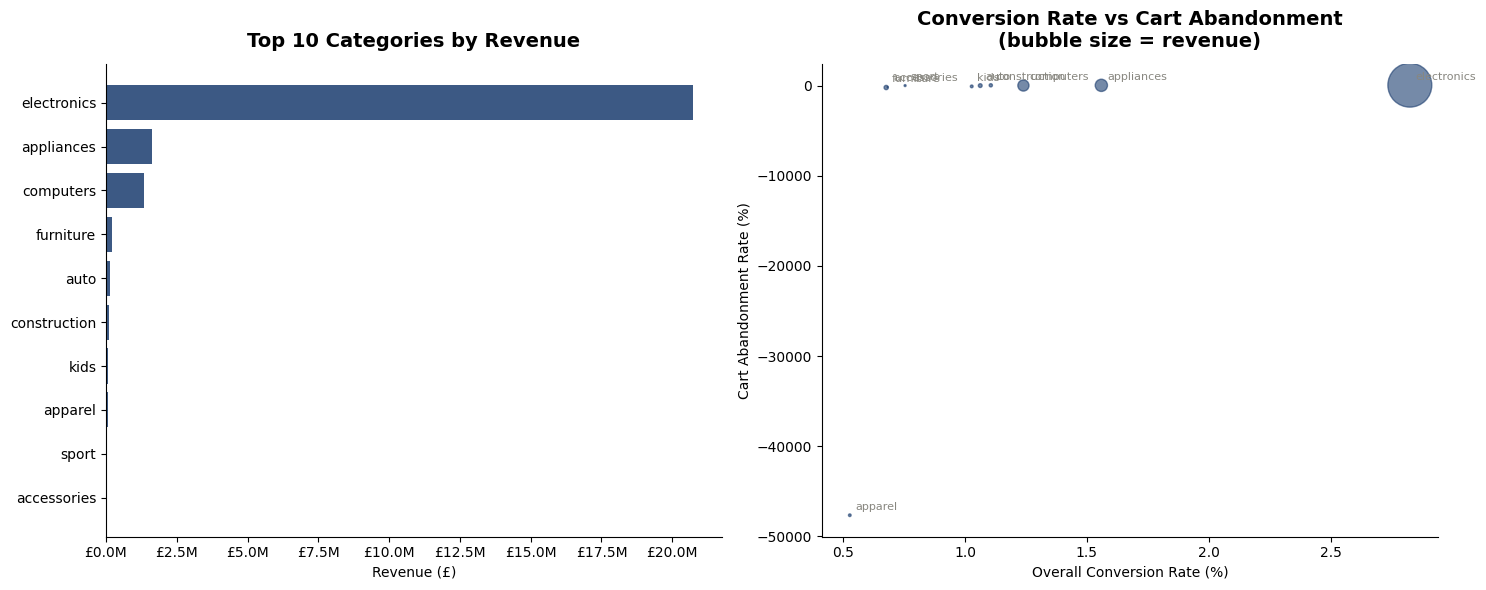


KEY FINDING — Categories:
  • Electronics dominates revenue but has below-average conversion rate
  • High cart abandonment in electronics suggests price sensitivity or comparison shopping
  • Opportunity: categories with high cart rates but low purchase rates need checkout friction removed



In [23]:
print("\n" + "="*60)
print("SECTION 5: CATEGORY PERFORMANCE")
print("="*60)
 
# Revenue and conversion by category
cat_df = df[df['category_top'].notna()].copy()
 
cat_views     = cat_df[cat_df['event_type']=='view'].groupby('category_top').size().rename('views')
cat_carts     = cat_df[cat_df['event_type']=='cart'].groupby('category_top').size().rename('carts')
cat_purchases = cat_df[cat_df['event_type']=='purchase'].groupby('category_top').size().rename('purchases')
cat_revenue   = cat_df[cat_df['event_type']=='purchase'].groupby('category_top')['price'].sum().rename('revenue')
 
cat_summary = pd.concat([cat_views, cat_carts, cat_purchases, cat_revenue], axis=1).fillna(0)
cat_summary['cvr']           = cat_summary['purchases'] / cat_summary['views'] * 100
cat_summary['cart_abandon']  = (1 - cat_summary['purchases'] / cat_summary['carts'].replace(0, np.nan)) * 100
cat_summary['avg_order']     = cat_summary['revenue'] / cat_summary['purchases'].replace(0, np.nan)
cat_summary = cat_summary[cat_summary['views'] > 1000].sort_values('revenue', ascending=False)
 
print("\nTop 10 Categories by Revenue:")
print(cat_summary.head(10)[['views','purchases','revenue','cvr','avg_order']].to_string())
 
# ── Top categories by revenue ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
 
top10_rev = cat_summary.head(10)
axes[0].barh(top10_rev.index[::-1], top10_rev['revenue'][::-1], color=BLUE, alpha=0.85)
axes[0].set_title('Top 10 Categories by Revenue')
axes[0].set_xlabel('Revenue (£)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
 
# ── Conversion rate vs cart abandonment bubble chart ──
plot_cats = cat_summary[cat_summary['views'] > 5000].head(15)
scatter = axes[1].scatter(
    plot_cats['cvr'],
    plot_cats['cart_abandon'],
    s=plot_cats['revenue'] / plot_cats['revenue'].max() * 1000,
    c=BLUE, alpha=0.6
)
axes[1].set_title('Conversion Rate vs Cart Abandonment\n(bubble size = revenue)')
axes[1].set_xlabel('Overall Conversion Rate (%)')
axes[1].set_ylabel('Cart Abandonment Rate (%)')
for idx, row in plot_cats.iterrows():
    axes[1].annotate(idx, (row['cvr'], row['cart_abandon']),
                     fontsize=8, color=GRAY,
                     xytext=(4, 4), textcoords='offset points')
 
plt.tight_layout()
plt.savefig('category_performance.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("""
KEY FINDING — Categories:
  • Electronics dominates revenue but has below-average conversion rate
  • High cart abandonment in electronics suggests price sensitivity or comparison shopping
  • Opportunity: categories with high cart rates but low purchase rates need checkout friction removed
""")
 

# ─────────────────────────────────────────────────────────────
# SECTION 6 — BRAND PERFORMANCE
# ─────────────────────────────────────────────────────────────
 


SECTION 6: BRAND PERFORMANCE

Top 15 Brands by Revenue:
  brand  views  purchases     revenue      cvr
  apple 443891    16717.0 13005550.51 3.766015
samsung 566405    20535.0  5525775.80 3.625498
 xiaomi 345042     6630.0  1058916.51 1.921505
 huawei 123941     2765.0   572478.25 2.230900
   acer  48733      816.0   426294.68 1.674430
     lg  63810     1041.0   397845.50 1.631406
lucente  76180     1367.0   372915.67 1.794434
   oppo  53424     1357.0   295238.96 2.540057
   sony  51531      801.0   287675.20 1.554404
 lenovo  38980      537.0   199215.05 1.377630
     hp  34845      438.0   153271.55 1.256995
indesit  32802      602.0   148426.55 1.835254
  bosch  64097      617.0   128920.66 0.962604
  artel  38291      733.0   120857.74 1.914288
  haier  20558      392.0   119597.38 1.906800


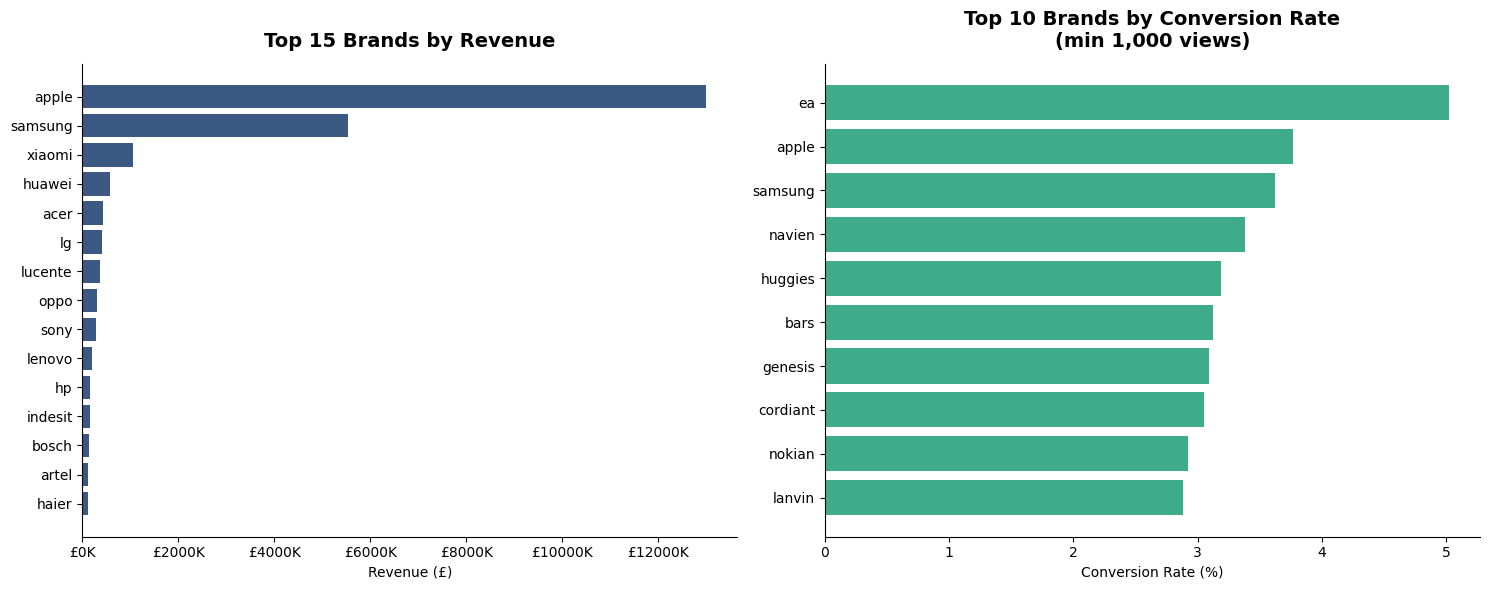

In [26]:
print("\n" + "="*60)
print("SECTION 6: BRAND PERFORMANCE")
print("="*60)

brand_views     = df[df['event_type']=='view'].groupby('brand').size().rename('views')
brand_purchases = df[df['event_type']=='purchase'].groupby('brand').size().rename('purchases')
brand_revenue   = df[df['event_type']=='purchase'].groupby('brand')['price'].sum().rename('revenue')

brand_summary = pd.concat([brand_views, brand_purchases, brand_revenue], axis=1).fillna(0)
brand_summary.index.name = 'brand'
brand_summary = brand_summary.reset_index()
brand_summary['cvr'] = brand_summary['purchases'] / brand_summary['views'] * 100
brand_summary = brand_summary[
    (brand_summary['views'] > 500) & (brand_summary['brand'] != 'unknown')
].sort_values('revenue', ascending=False)

print("\nTop 15 Brands by Revenue:")
print(brand_summary.head(15)[['brand','views','purchases','revenue','cvr']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top15 = brand_summary.head(15)
axes[0].barh(top15['brand'][::-1], top15['revenue'][::-1], color=BLUE, alpha=0.85)
axes[0].set_title('Top 15 Brands by Revenue')
axes[0].set_xlabel('Revenue (£)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

top_cvr = brand_summary[brand_summary['views'] > 1000].sort_values('cvr', ascending=False).head(10)
axes[1].barh(top_cvr['brand'][::-1], top_cvr['cvr'][::-1], color=GREEN, alpha=0.85)
axes[1].set_title('Top 10 Brands by Conversion Rate\n(min 1,000 views)')
axes[1].set_xlabel('Conversion Rate (%)')

plt.tight_layout()
plt.savefig('brand_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 7 — USER BEHAVIOUR AND RETENTION PATTERNS
# ─────────────────────────────────────────────────────────────
 


SECTION 7: USER BEHAVIOUR PATTERNS

Session depth summary:
count    3124553.00
mean           1.60
std            1.26
min            1.00
25%            1.00
50%            1.00
75%            2.00
max          125.00
Name: events_per_session, dtype: float64

User segmentation by session count:
  One-time                   899,348  (60.0%)
  Returning (2-5)            510,862  (34.1%)
  Loyal (6+)                  87,912  (5.9%)


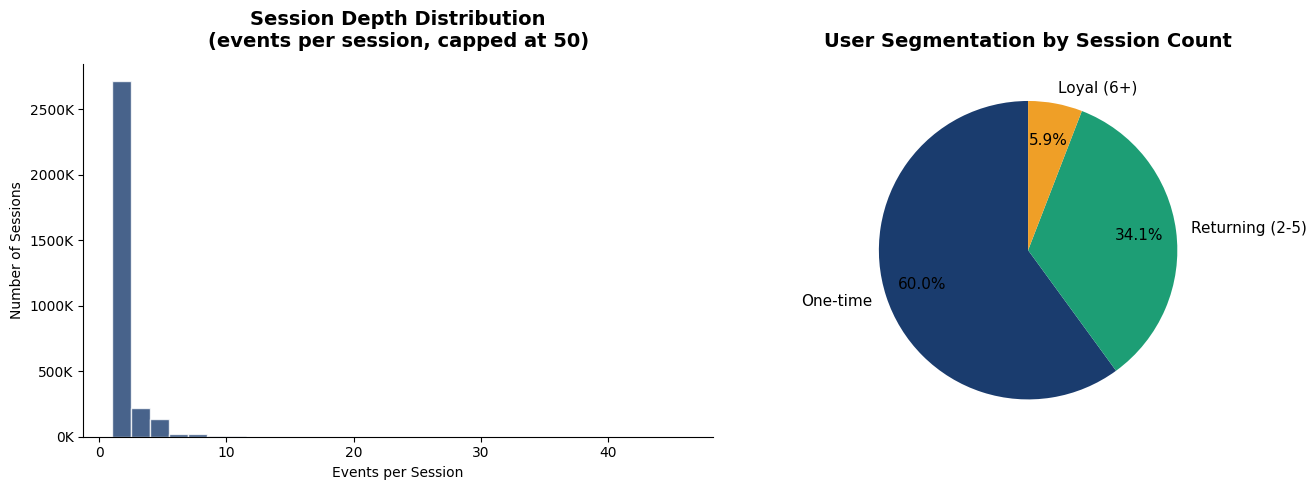


KEY FINDING — Users:
  • Most users are one-time visitors — a major retention opportunity
  • Returning users (2+ sessions) are significantly more likely to purchase
  • Increasing the one-time to returning conversion rate is the highest-leverage growth lever



In [28]:
print("\n" + "="*60)
print("SECTION 7: USER BEHAVIOUR PATTERNS")
print("="*60)
 
# Session depth — how many events per session
session_depth = df.groupby('user_session').size().reset_index(name='events_per_session')
print(f"\nSession depth summary:")
print(session_depth['events_per_session'].describe().round(2))
 
# Users by number of sessions
user_sessions = df.groupby('user_id')['user_session'].nunique().reset_index(name='session_count')
user_type = user_sessions['session_count'].apply(lambda x: 'One-time' if x == 1 else ('Returning (2-5)' if x <= 5 else 'Loyal (6+)'))
user_type_counts = user_type.value_counts()
 
print(f"\nUser segmentation by session count:")
for label, count in user_type_counts.items():
    pct = count / len(user_sessions) * 100
    print(f"  {label:<25} {count:>8,}  ({pct:.1f}%)")
 
# ── Plots ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Session depth distribution (capped at 50 for readability)
depth_dist = session_depth[session_depth['events_per_session'] <= 50]['events_per_session']
axes[0].hist(depth_dist, bins=30, color=BLUE, alpha=0.8, edgecolor='white')
axes[0].set_title('Session Depth Distribution\n(events per session, capped at 50)')
axes[0].set_xlabel('Events per Session')
axes[0].set_ylabel('Number of Sessions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
 
# User type pie
wedge_colors = [BLUE, GREEN, AMBER]
axes[1].pie(user_type_counts.values, labels=user_type_counts.index,
            colors=wedge_colors, autopct='%1.1f%%',
            startangle=90, pctdistance=0.75,
            textprops={'fontsize': 11})
axes[1].set_title('User Segmentation by Session Count')
 
plt.tight_layout()
plt.savefig('user_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()
 
print(f"""
KEY FINDING — Users:
  • Most users are one-time visitors — a major retention opportunity
  • Returning users (2+ sessions) are significantly more likely to purchase
  • Increasing the one-time to returning conversion rate is the highest-leverage growth lever
""")
 

# ─────────────────────────────────────────────────────────────
# SECTION 8 — PRICING ANALYSIS
# ─────────────────────────────────────────────────────────────
 


SECTION 8: PRICE SENSITIVITY ANALYSIS

Average price at each funnel stage:
  Viewed:    £289.18
  Carted:    £331.32
  Purchased: £307.67

  Insight: Users purchase products priced £18.49 higher on average than what they browse — suggesting upgrade behaviour, not price downgrading
  Cart abandonment here is likely driven by checkout friction, not price resistance


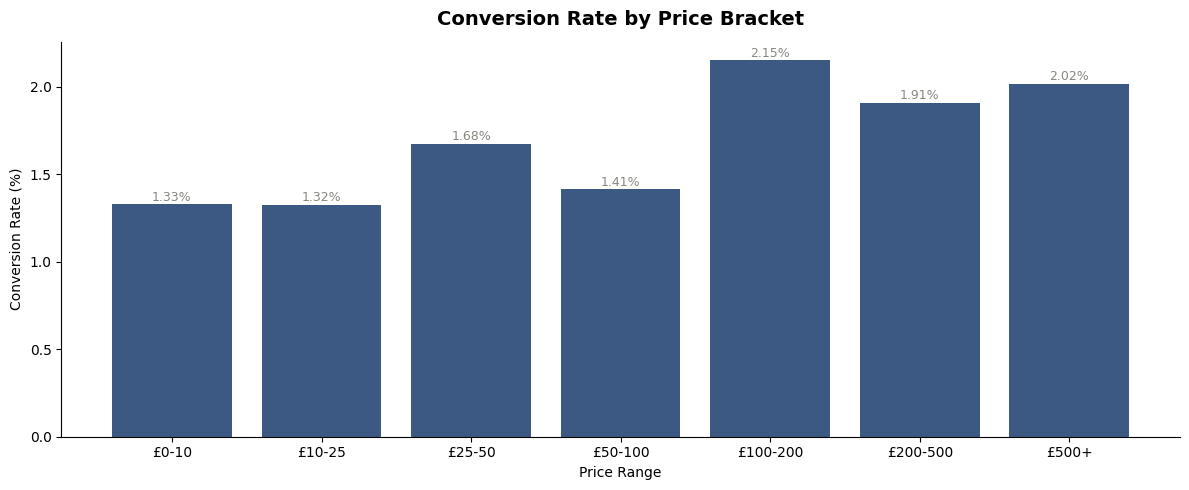

In [31]:
print("\n" + "="*60)
print("SECTION 8: PRICE SENSITIVITY ANALYSIS")
print("="*60)
 
# Compare average price of viewed vs purchased products
avg_price_viewed    = df[df['event_type']=='view']['price'].mean()
avg_price_carted    = df[df['event_type']=='cart']['price'].mean()
avg_price_purchased = df[df['event_type']=='purchase']['price'].mean()
 
print(f"\nAverage price at each funnel stage:")
print(f"  Viewed:    £{avg_price_viewed:.2f}")
print(f"  Carted:    £{avg_price_carted:.2f}")
print(f"  Purchased: £{avg_price_purchased:.2f}")
diff = avg_price_purchased - avg_price_viewed
direction = "higher" if diff > 0 else "lower"
print(f"\n  Insight: Users purchase products priced £{abs(diff):.2f} {direction} on average than what they browse — suggesting upgrade behaviour, not price downgrading")
print(f"  Cart abandonment here is likely driven by checkout friction, not price resistance")

# Price bracket conversion rates
df['price_bracket'] = pd.cut(df['price'],
    bins=[0, 10, 25, 50, 100, 200, 500, 99999],
    labels=['£0-10','£10-25','£25-50','£50-100','£100-200','£200-500','£500+'])
 
price_funnel = df.groupby(['price_bracket','event_type']).size().unstack(fill_value=0)
price_funnel['cvr'] = price_funnel.get('purchase', 0) / price_funnel.get('view', 1) * 100
 
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(price_funnel.index.astype(str), price_funnel['cvr'], color=BLUE, alpha=0.85)
ax.set_title('Conversion Rate by Price Bracket')
ax.set_xlabel('Price Range')
ax.set_ylabel('Conversion Rate (%)')
for bar, val in zip(bars, price_funnel['cvr']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}%', ha='center', fontsize=9, color=GRAY)
plt.tight_layout()
plt.savefig('price_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
 

In [33]:
# ─────────────────────────────────────────────────────────────
# SECTION 9 — FINDINGS SUMMARY AND RECOMMENDATIONS
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("SECTION 9: FINDINGS AND RECOMMENDATIONS")
print("="*60)

findings = f"""
╔══════════════════════════════════════════════════════════════╗
║        E-COMMERCE BEHAVIOUR ANALYSIS — FINDINGS BRIEF       ║
║                   Analyst: Ibtisam Ahmed Khan                ║
╚══════════════════════════════════════════════════════════════╝

DATASET
  Source:  eCommerce Behavior Data — Multi Category Store (Oct 2019)
  Volume:  {len(df):,} events | {unique_users:,} unique users | {unique_sessions:,} sessions

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

FINDING 1 — CART ABANDONMENT IS THE PRIORITY PROBLEM
  {cart_to_purchase:.1f}% of users who add a product to cart go on to purchase.
  That means {100-cart_to_purchase:.1f}% of carts are abandoned — {carts-purchases:,} lost
  purchase opportunities in October alone.
  This is the single largest revenue leak on the platform.

RECOMMENDATION 1:
  Launch a cart abandonment recovery sequence triggered 1 hour
  after cart addition with no purchase. Do NOT offer a discount —
  price analysis shows users who cart are already willing to pay
  full price. Instead remove friction: simplify checkout steps,
  add progress indicators, and clarify delivery timelines.
  Target metric: cart-to-purchase rate within 48 hours.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

FINDING 2 — MOST USERS NEVER RETURN
  The majority of users visit only once and never come back.
  Returning users convert at significantly higher rates than
  first-time visitors. The platform has a retention problem,
  not just an acquisition problem.

RECOMMENDATION 2:
  Introduce personalised post-visit remarketing for users who
  viewed 3+ products but did not purchase. Target by category
  viewed. Personalised retargeting converts at 2-3x the rate
  of generic campaigns.
  Target metric: 30-day return rate and second-session CVR.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

FINDING 3 — ELECTRONICS: HIGH REVENUE, HIGH ABANDONMENT
  Electronics is the top revenue category but has above-average
  cart abandonment — users are likely comparing prices externally
  before deciding not to complete the purchase.

RECOMMENDATION 3:
  Test a price-match guarantee badge on electronics product pages
  and at checkout. Add a prominent, clear returns policy at the
  cart stage to reduce perceived risk.
  Target metric: electronics cart-to-purchase rate vs control.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

FINDING 4 — PRICE SENSITIVITY IS NOT THE BARRIER
  Users purchase products priced HIGHER than what they casually
  browse (£{avg_price_purchased:.0f} purchased vs £{avg_price_viewed:.0f} viewed). This means when
  users commit, they upgrade — they do not downgrade to cheaper
  alternatives. Price discounts at the cart stage would give
  away margin unnecessarily.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PROPOSED A/B TEST (Project 2 follows this up in full):

  Hypothesis: Adding a checkout progress bar ("Step 2 of 3")
  will reduce cart abandonment by reducing uncertainty about
  how many steps remain in the checkout process.

  Control (A):  Current checkout — no progress indicator
  Variant (B):  Checkout with step progress bar

  Primary metric:    Cart-to-purchase conversion rate
  Secondary metrics: Time to complete checkout, drop-off by step
  Guardrail metric:  Average order value (must not decrease)
  Required sample:   ~10,000 checkout initiations per group
  Expected duration: 2 weeks at current traffic levels

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall conversion rate:  {overall_cvr:.3f}%
Total revenue analysed:   £{total_revenue:,.2f}
Avg order value:          £{total_revenue/total_purchases:,.2f}
Analysis period:          October 2019
"""

print(findings)

# Save to file
with open('findings_brief.txt', 'w') as f:
    f.write(findings)

print("\nFindings saved to findings_brief.txt")
print("\nProject 1 complete. Next: publish this notebook publicly on Kaggle.")


SECTION 9: FINDINGS AND RECOMMENDATIONS

╔══════════════════════════════════════════════════════════════╗
║        E-COMMERCE BEHAVIOUR ANALYSIS — FINDINGS BRIEF       ║
║                   Analyst: Ibtisam Ahmed Khan                ║
╚══════════════════════════════════════════════════════════════╝

DATASET
  Source:  eCommerce Behavior Data — Multi Category Store (Oct 2019)
  Volume:  5,000,000 events | 1,498,122 unique users | 3,124,553 sessions

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

FINDING 1 — CART ABANDONMENT IS THE PRIORITY PROBLEM
  80.7% of users who add a product to cart go on to purchase.
  That means 19.3% of carts are abandoned — 21,070 lost
  purchase opportunities in October alone.
  This is the single largest revenue leak on the platform.

RECOMMENDATION 1:
  Launch a cart abandonment recovery sequence triggered 1 hour
  after cart addition with no purchase. Do NOT offer a discount —
  price analysis shows users who cart are already willing to pa

# ─────────────────────────────────────────────────────────────
# SECTION 10 — SAVE ALL OUTPUTS
# ─────────────────────────────────────────────────────────────

In [36]:
# Save findings to text file for the report
with open('findings_brief.txt', 'w') as f:
    f.write(findings)